In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
# Load Titanic dataset (built into seaborn, no download needed)
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


2.check missing values and dtypes

In [5]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Missing values:
 survived         0
pclass           0
sex              0
age 

3: Handle missing values

In [6]:
# Drop columns that are too sparse or redundant
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'])

# Fill missing age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing embarked with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Verify
print(df.isnull().sum())
print(df.shape)

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64
(891, 9)


4: Feature selection and encoding

In [7]:
# One-hot encode 'embarked' (3 categories: S, C, Q — no natural order)
df = pd.get_dummies(df, columns=['embarked'], prefix='embarked')

# Label encode 'sex' (binary: male/female)
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])   # male=1, female=0

# Convert 'alone' bool to int
df['alone'] = df['alone'].astype(int)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_C,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,0,False,False,True
1,1,1,0,38.0,1,0,71.2833,0,True,False,False
2,1,3,0,26.0,0,0,7.9250,1,False,False,True
3,1,1,0,35.0,1,0,53.1000,0,False,False,True
4,0,3,1,35.0,0,0,8.0500,1,False,False,True


In [8]:
bool_cols = ['embarked_C', 'embarked_Q', 'embarked_S']
df[bool_cols] = df[bool_cols].astype(int)

5: Normalize + EDA

In [9]:
# Scale numeric features
scaler = StandardScaler()
num_cols = ['age', 'fare', 'sibsp', 'parch']
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_C,embarked_Q,embarked_S
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,0,0,0,1
1,1,1,0,0.663861,0.432793,-0.473674,0.786845,0,1,0,0
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,1,0,0,1
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,0,0,0,1
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,1,0,0,1


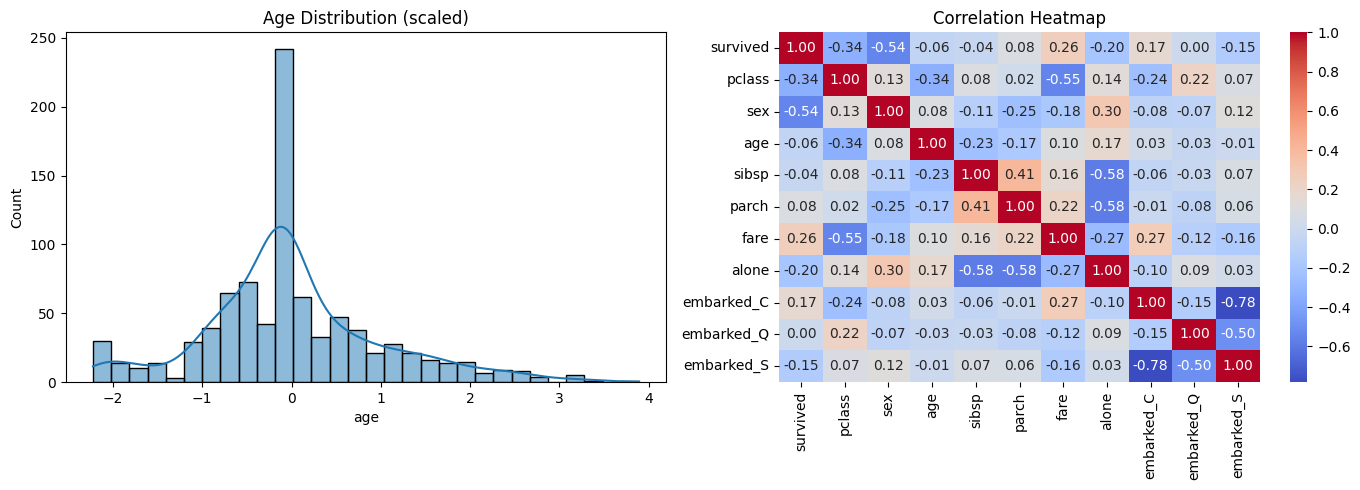

In [10]:
# EDA plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution (scaled)')

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

WEEK-2


Step 1: Train/test split

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(712, 10) (179, 10)


Step 2: Import all the models and metrics we'll need

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Step 3: Train and evaluate each model

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.804469   0.783333  0.681159  0.728682
Decision Tree        0.832402   0.800000  0.753623  0.776119
Random Forest        0.810056   0.786885  0.695652  0.738462
KNN                  0.804469   0.774194  0.695652  0.732824


Step 4: Visualize the comparison + confusion matrices

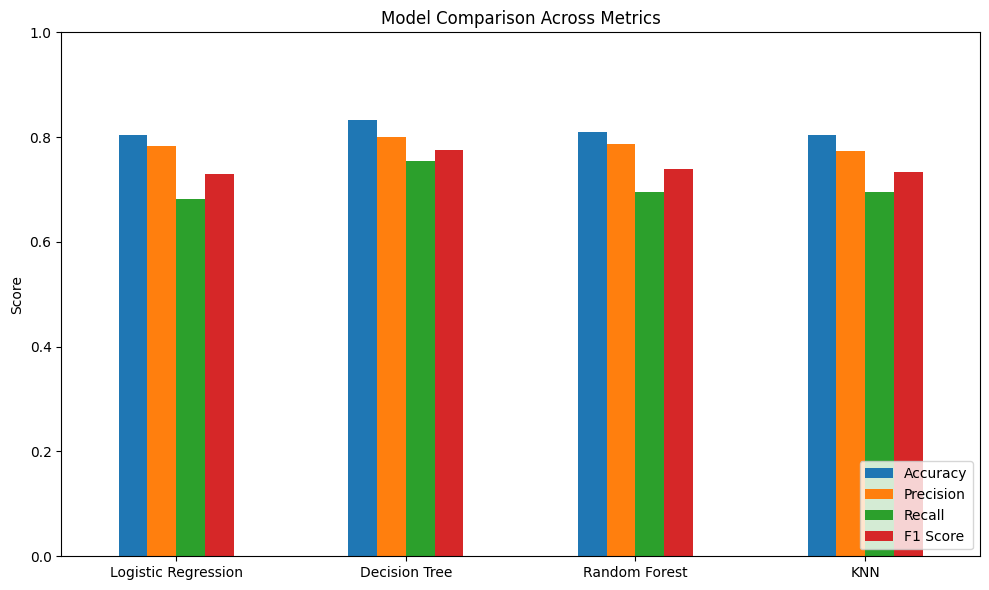

In [14]:
# Bar chart comparing all metrics across models
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

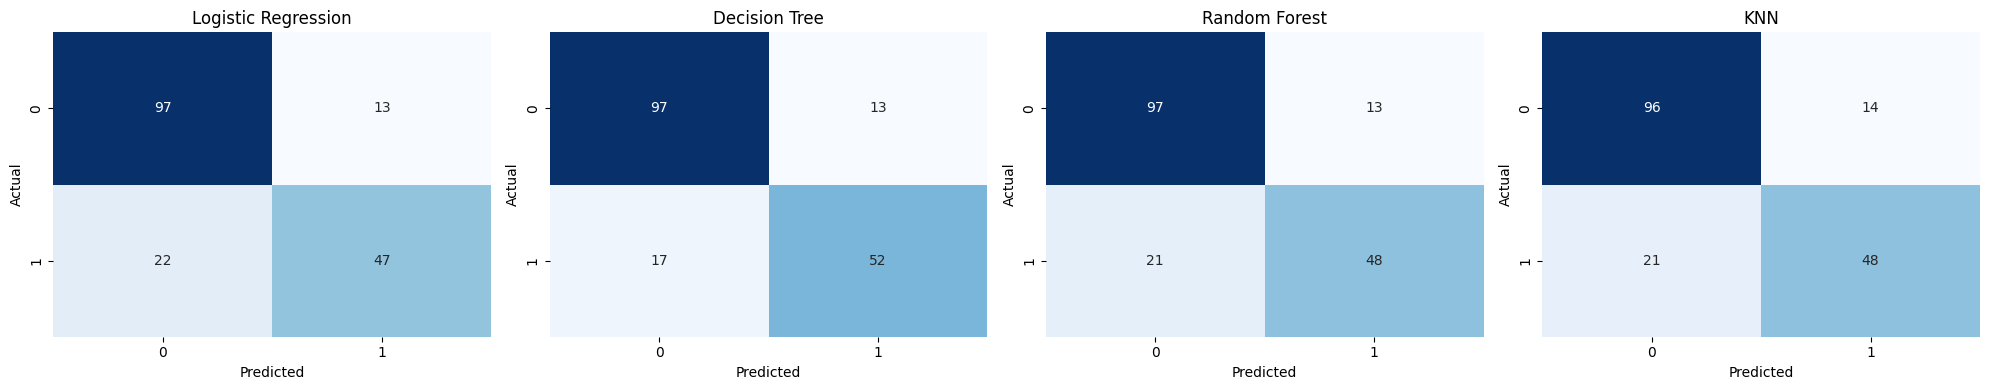

In [15]:
# Confusion matrices for all 4 models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()